In [1]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import plotly.express as px
import plotly.graph_objects as go
from sklearn.mixture import GaussianMixture
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm

In [2]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_all = df.copy()
df_all = df_all[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]']]
df_ST = df_all[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']]

In [3]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)
torch.manual_seed(seed)

In [4]:
# Extract values into a tensor
X = torch.tensor(df_ST.values, dtype=torch.float32)
dataset = TensorDataset(X)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [5]:
# Define Variational Autoencoder

class VAE(nn.Module):
    def __init__(self, input_dim=3, latent_dim=2):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, 16)
        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_logvar = nn.Linear(16, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 16)
        self.fc3 = nn.Linear(16, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return self.fc3(h)     # no sigmoid for real-valued data

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [6]:
# Define loss function (mse and KL divergence)
def vae_loss(recon_x, x, mu, logvar):
    mse = F.mse_loss(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return mse + kld

In [7]:
import copy

device = "cuda" if torch.cuda.is_available() else "cpu"
model = VAE(input_dim=2, latent_dim=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 50
patience = 5
best_loss = float("inf")
patience_counter = 0
best_model_state = None

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for batch in loader:
        x = batch[0].to(device)
        optimizer.zero_grad()

        recon, mu, logvar = model(x)
        loss = vae_loss(recon, x, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataset)
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f}")

    # ---- Early stopping logic ----
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

Epoch 1 | Loss: 3.2702
Epoch 2 | Loss: 2.0640
Epoch 3 | Loss: 2.0128
Epoch 4 | Loss: 1.9862
Epoch 5 | Loss: 1.9746
Epoch 6 | Loss: 1.9721
Epoch 7 | Loss: 1.9707
Epoch 8 | Loss: 1.9692
Epoch 9 | Loss: 1.9688
Epoch 10 | Loss: 1.9667
Epoch 11 | Loss: 1.9643
Epoch 12 | Loss: 1.9637
Epoch 13 | Loss: 1.9628
Epoch 14 | Loss: 1.9622
Epoch 15 | Loss: 1.9618
Epoch 16 | Loss: 1.9614
Epoch 17 | Loss: 1.9612
Epoch 18 | Loss: 1.9608
Epoch 19 | Loss: 1.9599
Epoch 20 | Loss: 1.9601
Epoch 21 | Loss: 1.9596
Epoch 22 | Loss: 1.9593
Epoch 23 | Loss: 1.9589
Epoch 24 | Loss: 1.9585
Epoch 25 | Loss: 1.9584
Epoch 26 | Loss: 1.9581
Epoch 27 | Loss: 1.9578
Epoch 28 | Loss: 1.9581
Epoch 29 | Loss: 1.9575
Epoch 30 | Loss: 1.9573
Epoch 31 | Loss: 1.9569
Epoch 32 | Loss: 1.9569
Epoch 33 | Loss: 1.9571
Epoch 34 | Loss: 1.9560
Epoch 35 | Loss: 1.9561
Epoch 36 | Loss: 1.9559
Epoch 37 | Loss: 1.9562
Epoch 38 | Loss: 1.9556
Epoch 39 | Loss: 1.9550
Epoch 40 | Loss: 1.9543
Epoch 41 | Loss: 1.9545
Epoch 42 | Loss: 1.9538
E

In [8]:
model.eval()
with torch.no_grad():
    mu, logvar = model.encode(X.to(device))
    z = mu.cpu()   # latent representation

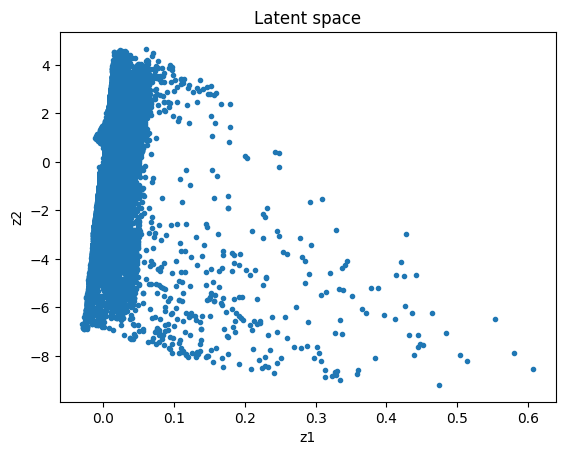

In [9]:
plt.scatter(z[:,0].cpu().tolist(), z[:,1].cpu().tolist(), marker='.')
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Latent space")
plt.show()

In [10]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed)
    gmm.fit(z.cpu().numpy())
    bic_scores.append(gmm.bic(z.cpu().numpy()))

/Users/franciscagomes/PhD/WM_class/.venv/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


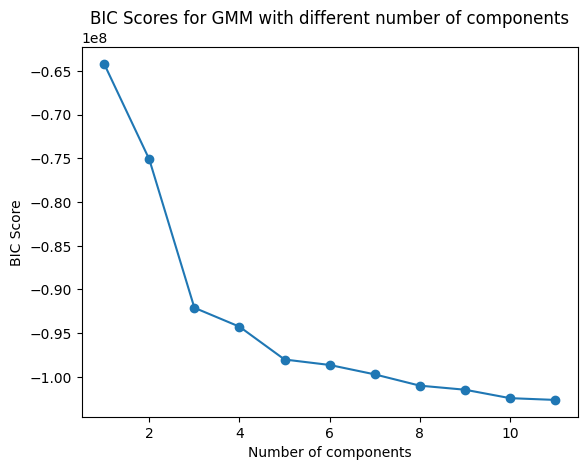

In [11]:
# BIC score plot
plt.plot(n_components_range, bic_scores, marker='o')
plt.xlabel("Number of components")  
plt.ylabel("BIC Score")
plt.title("BIC Scores for GMM with different number of components")
plt.show()

In [12]:
with torch.no_grad():
    recon = model(X.to(device))[0].cpu().numpy()

In [25]:
optimal_n_components = 5

In [26]:
gmm = GaussianMixture(n_components=optimal_n_components, random_state=seed)
gmm.fit(z)
gmm_labels = gmm.predict(z)
df_all['gmm_label'] = gmm_labels.astype(int)

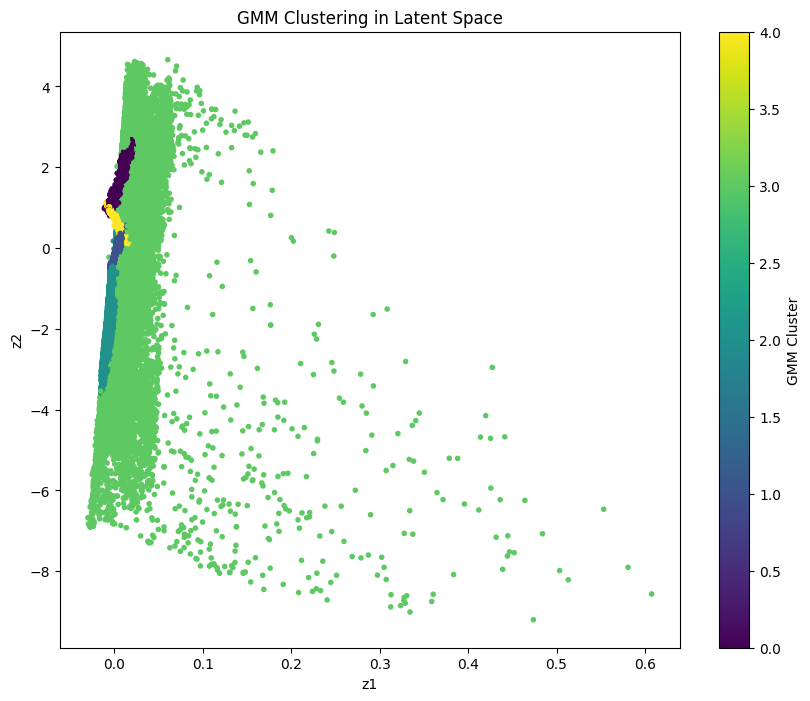

In [27]:
# Plot GMM on latent space with probability contours for each cluster
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
scatter = ax.scatter(z[:,0].cpu().tolist(), z[:,1].cpu().tolist(), c=gmm_labels, cmap='viridis', marker='.')
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("GMM Clustering in Latent Space")
plt.colorbar(scatter, label='GMM Cluster')
plt.show()

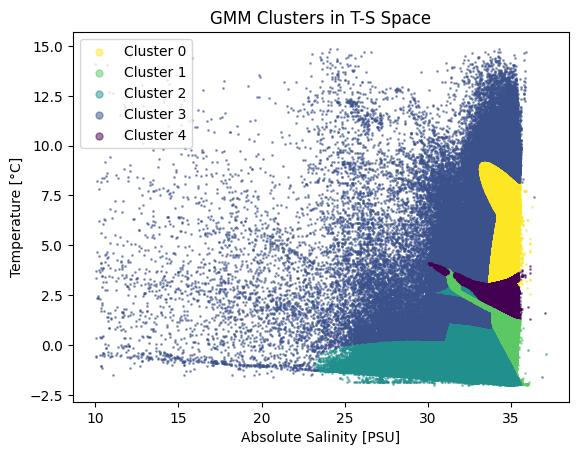

In [28]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, optimal_n_components))

for i in range(optimal_n_components):
    mask = df_all['gmm_label'] == i
    plt.scatter(
        df_ST.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_ST.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [29]:
# Sample for plotting
df_sampled = df_all.sample(n=100000, random_state=seed)

In [30]:
# Compute data centroid (mean location)
center_lat = df_all['Latitude_[deg_N]'].mean()
center_lon = df_all['Longitude_[deg_E]'].mean()

colors = px.colors.sample_colorscale(
    px.colors.sequential.Plasma, # Colour scale same as continuous colour bar version but sampled to be discrete
    np.linspace(0, 1, optimal_n_components)
)

# Stepped colorscale
discrete_colorscale = []
for i, c in enumerate(colors):
    discrete_colorscale.append([i / optimal_n_components, c])
    discrete_colorscale.append([(i + 1) / optimal_n_components, c])

fig = px.scatter_geo(
    df_sampled,
    lat='Latitude_[deg_N]',
    lon='Longitude_[deg_E]',
    color='gmm_label',
    color_continuous_scale=discrete_colorscale,
    range_color=(0, optimal_n_components),
    title="GMM clusters using TSO on geographic map"
)

fig.update_traces(
    marker=dict(size=5, opacity=0.9)
)

fig.update_coloraxes(showscale=False)  # hide colorbar

for i, c in enumerate(colors):
    fig.add_trace(
        go.Scattergeo(
            lat=[None], lon=[None],   # invisible
            mode="markers",
            marker=dict(size=8, color=c),
            name=f"Cluster {i}",
            showlegend=True
        )
    )

fig.update_geos(
    projection_type="orthographic",
    projection_rotation=dict(lat=center_lat, lon=center_lon),
    showcoastlines=True,
    showcountries=True
)

fig.update_layout(
    height=800,
    width=800,
    legend_title_text="GMM Cluster",
    legend_traceorder="normal"
)

fig.show()

In [31]:
colors = px.colors.sample_colorscale(
    px.colors.sequential.Plasma,
    np.linspace(0, 1, optimal_n_components)
)

# Stepped colorscale
discrete_colorscale = []
for i, c in enumerate(colors):
    discrete_colorscale.append([i / optimal_n_components, c])
    discrete_colorscale.append([(i + 1) / optimal_n_components, c])

fig_3d = px.scatter_3d(
    df_sampled,
    x='Latitude_[deg_N]',
    y='Longitude_[deg_E]',
    z='Depth_[m]',
    color='gmm_label',
    color_continuous_scale=discrete_colorscale,
    range_color=(0, optimal_n_components),
    title="3D Scatter Lat-Lon-Depth plot of GMM clusters"
)

fig_3d.update_traces(
    marker=dict(
        size=5
    )
)

fig_3d.update_coloraxes(showscale=False)  # hide colorbar

for i, c in enumerate(colors):
    fig_3d.add_trace(
        go.Scatter3d(
            x=[None], y=[None], z=[None],
            mode="markers",
            marker=dict(size=8, color=c),
            name=f"Cluster {i}",
            showlegend=True
        )
    )

fig_3d.update_layout(
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Depth (m)',
        zaxis=dict(autorange='reversed')
    ),
    height=800,
    width=800,
    legend_title_text="GMM Cluster",
    legend_traceorder="normal"
)

fig_3d.show()

In [32]:
def cross_sec_lon(lat_value, tol=0.5):
    df_lon_slice = df_all[
        (df_all['Longitude_[deg_E]'] >= lat_value - tol) &
        (df_all['Longitude_[deg_E]'] <= lat_value + tol)
    ]

    n = optimal_n_components

    # Sample full sequential colormap discretely
    base_cmap = plt.cm.viridis
    colors = base_cmap(np.linspace(0, 1, n))
    cmap = ListedColormap(colors)

    # Discrete normalization
    norm = BoundaryNorm(np.arange(-0.5, n + 0.5, 1), cmap.N)

    plt.figure(figsize=(10, 6))

    sc = plt.scatter(
        df_lon_slice['Latitude_[deg_N]'],
        df_lon_slice['Depth_[m]'],
        c=df_lon_slice['gmm_label'],
        cmap=cmap,
        norm=norm,
        s=8,
        alpha=0.6
    )

    plt.gca().invert_yaxis()
    plt.xlabel('Longitude [deg E]')
    plt.ylabel('Depth [m]')
    plt.title(f'GMM Clusters in Longitude–Depth Cross Section at Latitude ~ {lat_value}°N')

    # ---- Discrete legend (dummy handles) ----
    handles = [
        Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            markersize=6,
            markerfacecolor=colors[i],
            markeredgecolor='none',
            label=f'Cluster {i}'
        )
        for i in range(n)
    ]

    plt.legend(
        handles=handles,
        title='GMM Cluster',
        loc='lower left',
    )

    plt.tight_layout()
    plt.show()

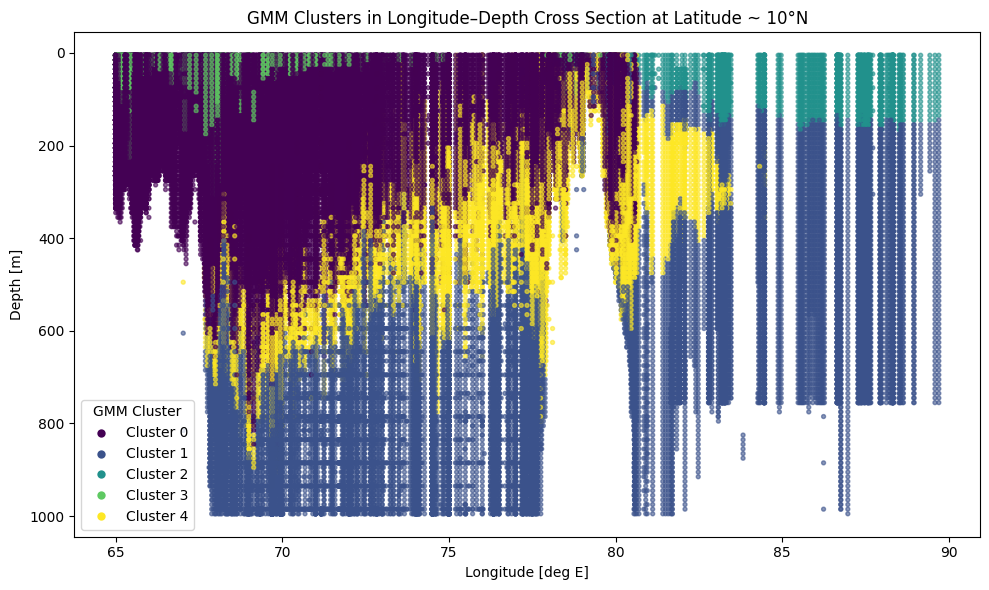

In [33]:
# Plot cross section for specific longitude slice
lon_slice = 10
cross_sec_lon(lon_slice, tol=0.5)

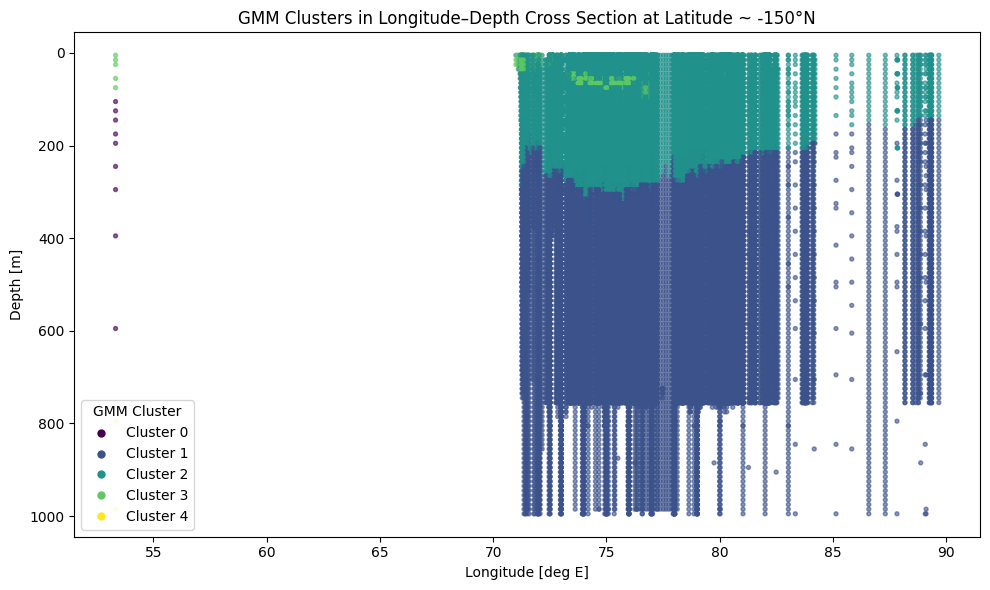

In [34]:
lat_val= -150
cross_sec_lon(lat_val, tol=0.5)

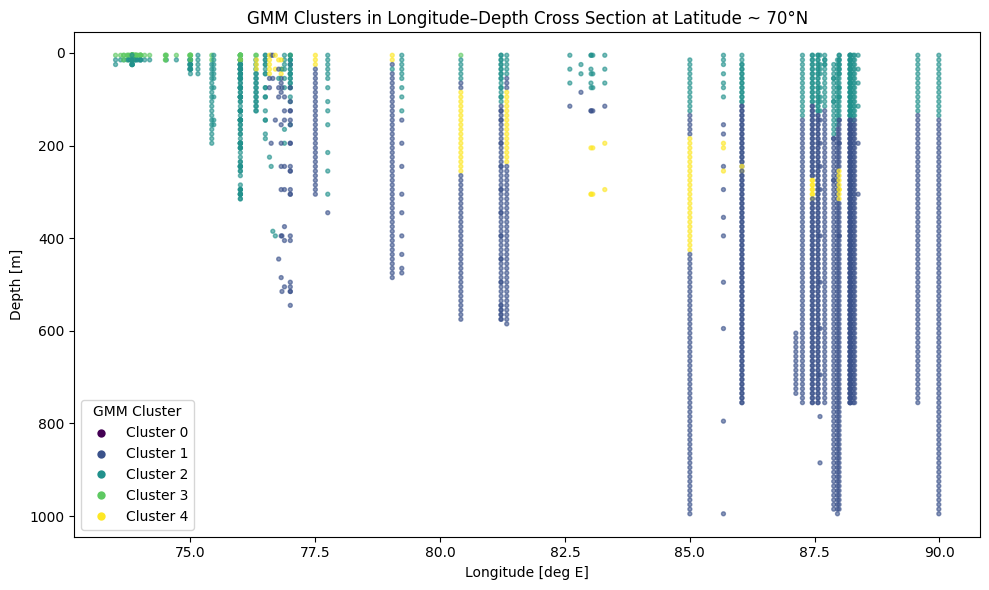

In [35]:
lat = 70
cross_sec_lon(lat, tol=0.5)

In [36]:
# Loss of information
z_mean, z_log_var = model.encode(torch.tensor(df_ST.values, dtype=torch.float32))
X_recon_vae = model.decode(z_mean)
X_recon_vae = X_recon_vae.detach().numpy()
mse = np.mean((df_ST - X_recon_vae) ** 2)
print(f'Mean Squared Error of VAE reconstruction: {mse}')

Mean Squared Error of VAE reconstruction: 0.14393454025255292
